In [1]:
!pip install wfdb==4.3.1 neurokit2

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 5.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 688.9/688.9 kB 38.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 86.1 MB/s eta 0:00:00
  Attempting uninstall: pandas
    Found existing installation: pandas 2.2.2
    Uninstalling pandas-2.2.2:
      Successfully uninstalled pandas-2.2.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.2, but you have pandas 2.3.3 which is incompatible.


In [2]:
import wfdb
import matplotlib.pyplot as plt

In [3]:
#loads neurokit

import neurokit2 as nk
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [4]:

rec_path = '/files/p1000/p10000117/s45090959/45090959'
recordid = "45090959"
rd_record = wfdb.rdrecord(recordid, pn_dir='mimic-iv-ecg/1.0/files/p1000/p10000117/s45090959')

In [5]:
#10 seconds of ECG material
rd_record.p_signal.shape
ecg_signal = rd_record.p_signal[:,1]
#processess the raw ECG signal
signals, info = nk.ecg_process(ecg_signal, sampling_rate=rd_record.fs)


In [6]:
#BG not sure if the plot is necessary / helpful, could just list the available signals and info keys

# Extracts clean ECG and R-peaks location
rpeaks = info["ECG_R_Peaks"]
cleaned_ecg = signals["ECG_Clean"]

# List signals and info keys
print("Signals:")
for key in signals.keys():
    print(key)

print("\nInfo keys:")
for key in info.keys():
    print(key)

Signals:
ECG_Raw
ECG_Clean
ECG_Rate
ECG_Quality
ECG_R_Peaks
ECG_P_Peaks
ECG_P_Onsets
ECG_P_Offsets
ECG_Q_Peaks
ECG_R_Onsets
ECG_R_Offsets
ECG_S_Peaks
ECG_T_Peaks
ECG_T_Onsets
ECG_T_Offsets
ECG_Phase_Atrial
ECG_Phase_Completion_Atrial
ECG_Phase_Ventricular
ECG_Phase_Completion_Ventricular

Info keys:
method_peaks
method_fixpeaks
ECG_R_Peaks
ECG_R_Peaks_Uncorrected
ECG_fixpeaks_ectopic
ECG_fixpeaks_missed
ECG_fixpeaks_extra
ECG_fixpeaks_longshort
ECG_fixpeaks_method
ECG_fixpeaks_rr
ECG_fixpeaks_drrs
ECG_fixpeaks_mrrs
ECG_fixpeaks_s12
ECG_fixpeaks_s22
ECG_fixpeaks_c1
ECG_fixpeaks_c2
sampling_rate
ECG_P_Peaks
ECG_P_Onsets
ECG_P_Offsets
ECG_Q_Peaks
ECG_R_Onsets
ECG_R_Offsets
ECG_S_Peaks
ECG_T_Peaks
ECG_T_Onsets
ECG_T_Offsets


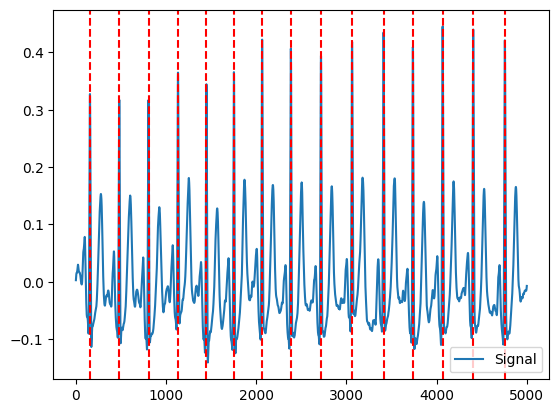

In [7]:
# Visualize R-peaks in ECG signal
plot = nk.events_plot(rpeaks, cleaned_ecg)

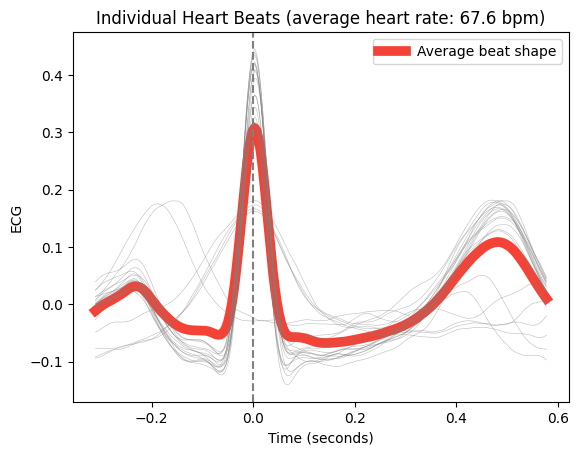

In [8]:
# Plotting all the heart beats
epochs = nk.ecg_segment(cleaned_ecg, rpeaks=None, sampling_rate=250, show=True)

In [9]:
tachycardia_count = 0
brachycardia_count = 0
sinus_count = 0

#Get list of ECG records from dataset
records = wfdb.get_record_list("mimic-iv-ecg/1.0/files/p1000")

num_ecgs_to_process = 100;

#Loop through the first __ ECGs
for full_recordid in records[:num_ecgs_to_process]:

    #get record ID from path
    record_id = full_recordid.split("/")[-1]

    #get folder path
    folder_path = full_recordid.rsplit("/", 1)[0]

    #Load ECG record
    rd_record = wfdb.rdrecord(record_id, pn_dir=f"mimic-iv-ecg/1.0/files/p1000/{folder_path}")

    #Sampling frequency
    fs = rd_record.fs

    #to store heart rate from each lead
    lead_hrs = []

    #Loop through all 12 leads
    for lead_idx in range(12):

        #Get signal for current lead
        signal = rd_record.p_signal[:, lead_idx]

        #remove nan values
        signal = signal[~np.isnan(signal)]

        #Clean ECG signal
        cleaned = nk.ecg_clean(signal, sampling_rate=fs)

        #Detect R-peaks
        peaks = nk.ecg_findpeaks(cleaned, sampling_rate=fs)
        rpeaks = peaks["ECG_R_Peaks"]

        #Calculate heart rate if enough beats detected to get a heart rate and hrv
        if len(rpeaks) > 2:
            rr = np.diff(rpeaks) / fs
            hr = 60 / np.mean(rr)
            lead_hrs.append(hr)

        #If this is Lead II (where hrv is calculated), compute HRV
        #****Note that RMSSD for 10-second ECGs is extremely discrepant.****
        if lead_idx == 1 and len(rpeaks) > 2:
            rr_lead2 = np.diff(rpeaks) / fs
            rmssd = np.sqrt(np.mean(np.diff(rr_lead2) ** 2)) * 1000 #a short-term hrv measurement


    #After iterating through all leads: compute average heart rate of all 12 leads
    if len(lead_hrs) > 0:
        avg_hr = np.mean(lead_hrs)

        #BPM classifier
        if avg_hr > 100:
            label = "tachycardia"
            tachycardia_count += 1
        elif avg_hr < 60:
            label = "brachycardia"
            brachycardia_count += 1
        else:
            label = "sinus"
            sinus_count += 1

        print(f"{full_recordid}: Avg HR={avg_hr:.2f} BPM, RMSSD={rmssd:.2f} ms, {label}")

    else:
        print(f"{full_recordid}: Not enough peaks detected")

p10000032/s40689238/40689238: Avg HR=91.13 BPM, RMSSD=9.78 ms, sinus
p10000032/s44458630/44458630: Avg HR=83.30 BPM, RMSSD=18.64 ms, sinus
p10000032/s49036311/49036311: Avg HR=100.24 BPM, RMSSD=7.37 ms, tachycardia
p10000117/s45090959/45090959: Avg HR=91.29 BPM, RMSSD=21.92 ms, sinus
p10000117/s48446569/48446569: Avg HR=90.93 BPM, RMSSD=12.45 ms, sinus
p10000285/s42709053/42709053: Avg HR=72.41 BPM, RMSSD=24.71 ms, sinus
p10000560/s41445586/41445586: Avg HR=64.70 BPM, RMSSD=88.68 ms, sinus
p10000560/s42695383/42695383: Avg HR=65.44 BPM, RMSSD=35.04 ms, sinus
p10000635/s40067704/40067704: Avg HR=65.55 BPM, RMSSD=558.01 ms, sinus
p10000635/s42947358/42947358: Avg HR=65.25 BPM, RMSSD=359.23 ms, sinus
p10000635/s43522917/43522917: Avg HR=57.46 BPM, RMSSD=42.11 ms, brachycardia
p10000635/s44095784/44095784: Avg HR=63.94 BPM, RMSSD=32.33 ms, sinus
p10000635/s45386375/45386375: Avg HR=63.00 BPM, RMSSD=94.86 ms, sinus
p10000635/s48339811/48339811: Avg HR=57.70 BPM, RMSSD=101.19 ms, brachycardi

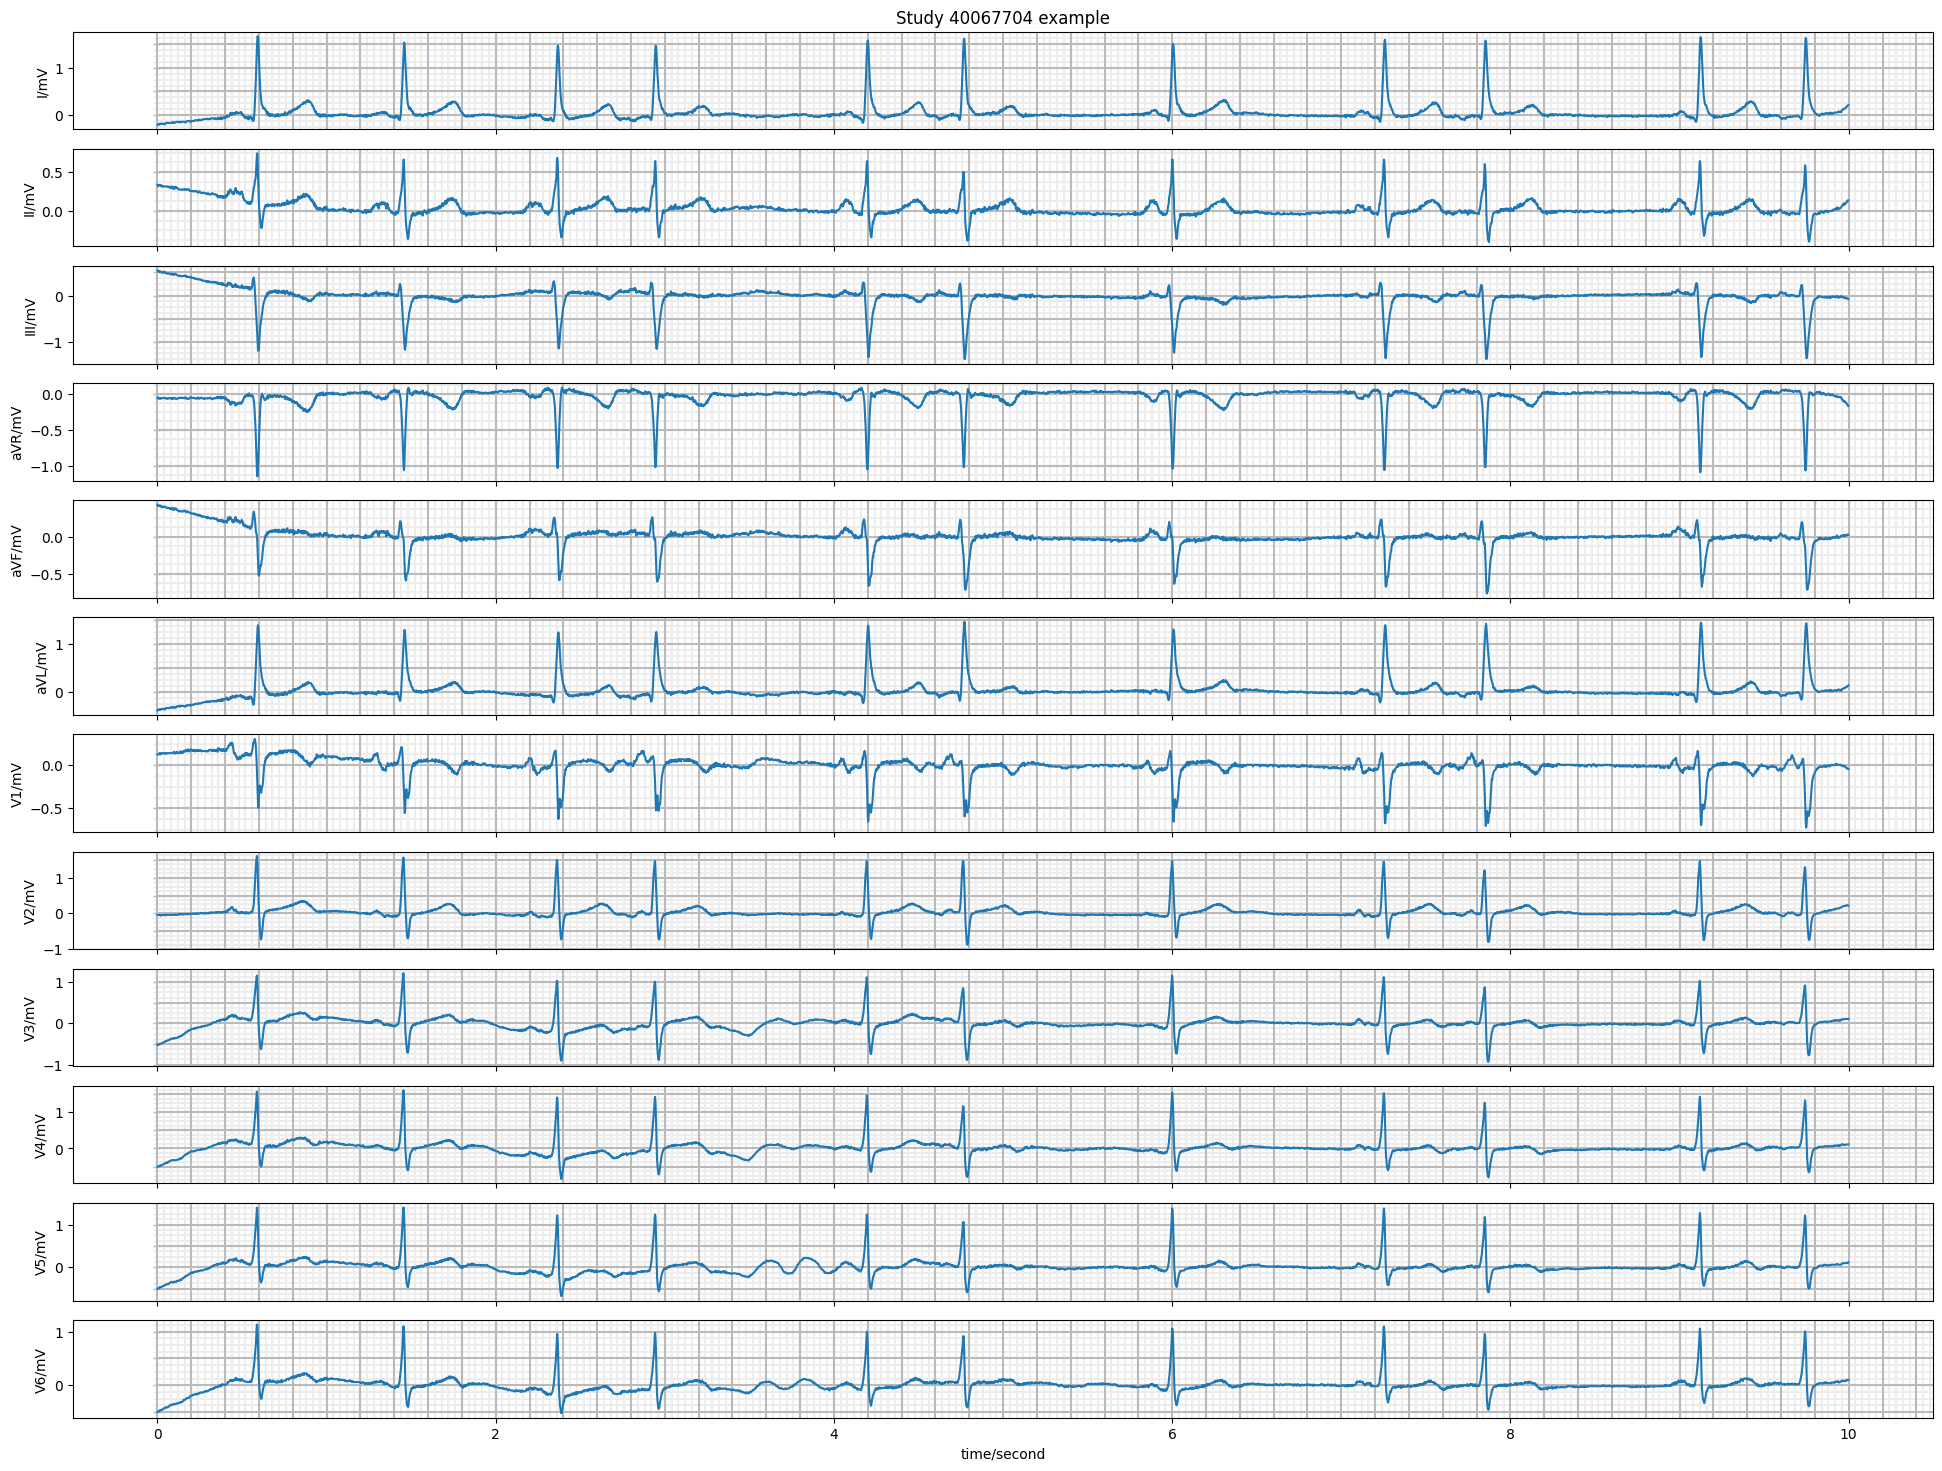

In [13]:

rec_path = '/files/p1000/p10000635/s40067704/40067704'
recordid = "40067704"
rd_record = wfdb.rdrecord(recordid, pn_dir='mimic-iv-ecg/1.0/files/p1000/p10000635/s40067704')
wfdb.plot_wfdb(record = rd_record, figsize=(24, 18), title =f'Study {recordid} example', ecg_grids='all')


In [11]:
wfdb.plot

<module 'wfdb.plot' from '/usr/local/lib/python3.12/dist-packages/wfdb/plot/__init__.py'>

In [12]:
print(f"tachycardia count: {tachycardia_count}%")
print(f"brachycardia count: {brachycardia_count}%")
print(f"sinus count: {sinus_count}%")

tachycardia count: 10%
brachycardia count: 13%
sinus count: 77%
